In [1]:
from google.colab import files
uploades =files.upload()

Saving heart (1).csv to heart (1).csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("heart (1).csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:


df = df.dropna()
df = df.drop_duplicates()
df.columns = df.columns.str.lower().str.strip()
df = df[df["age"] > 0]

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [ ]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [ ]:
 df.corr()["target"].sort_values(ascending=False)

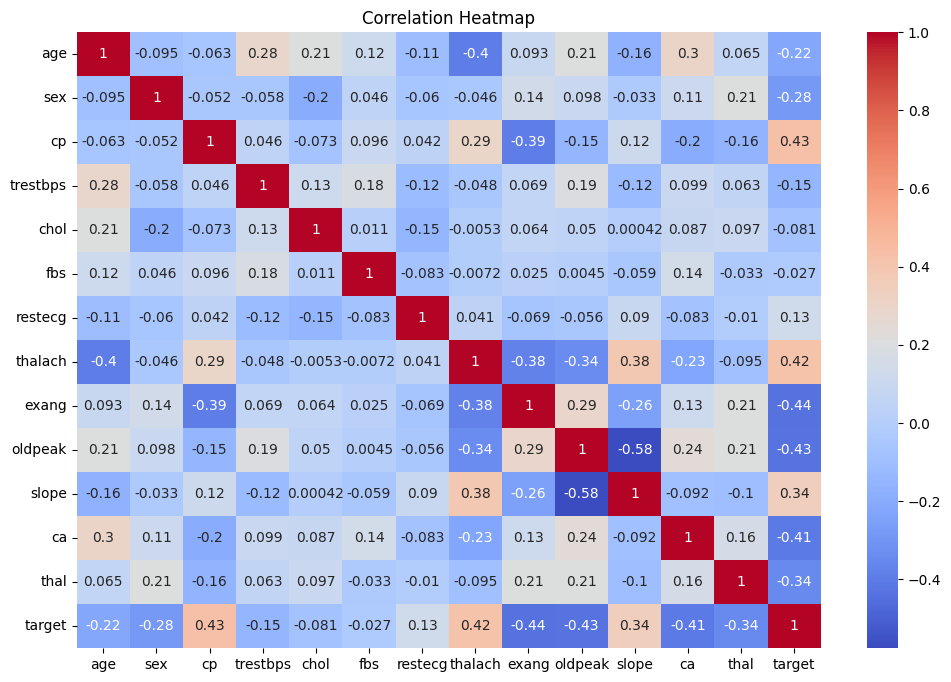

In [ ]:


plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

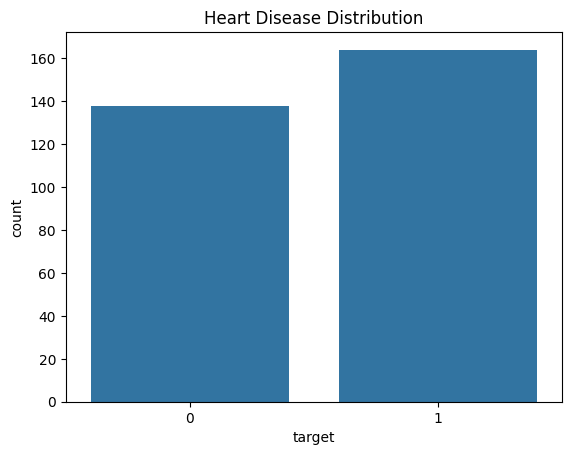

In [ ]:
sns.countplot(x="target", data=df)
plt.title("Heart Disease Distribution")
plt.show()

In [ ]:
cp_analysis = df.groupby("cp")["target"].mean() * 100
print(cp_analysis)

cp
0    27.272727
1    82.000000
2    79.069767
3    69.565217
Name: target, dtype: float64


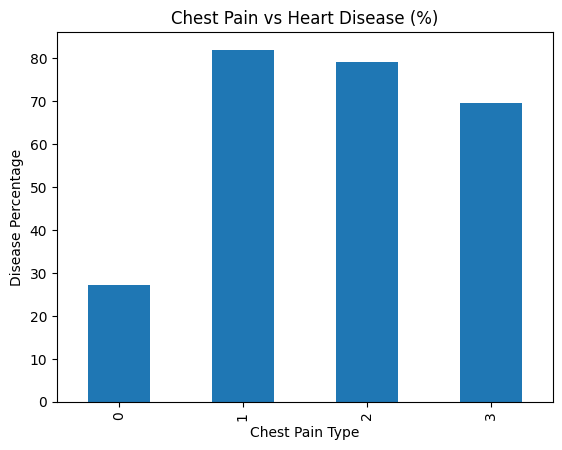

In [ ]:
cp_analysis.plot(kind="bar")
plt.title("Chest Pain vs Heart Disease (%)")
plt.xlabel("Chest Pain Type")
plt.ylabel("Disease Percentage")
plt.show()

In [ ]:
df.groupby("target")["oldpeak"].mean()

,oldpeak
target,
0,1.585507
1,0.586585


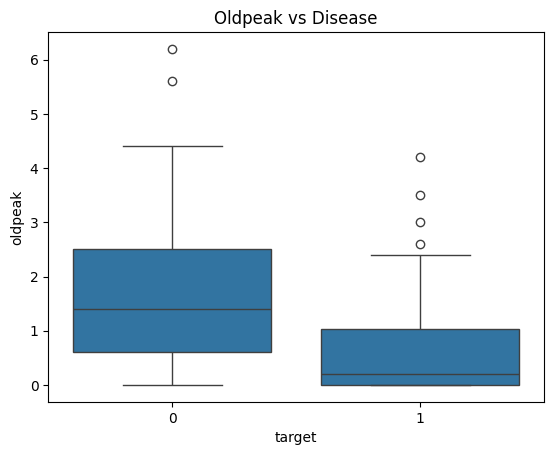

In [ ]:
sns.boxplot(x="target", y="oldpeak", data=df)
plt.title("Oldpeak vs Disease")
plt.show()

In [ ]:
df.groupby("exang")["target"].mean() * 100

,target
exang,
0,69.458128
1,23.232323


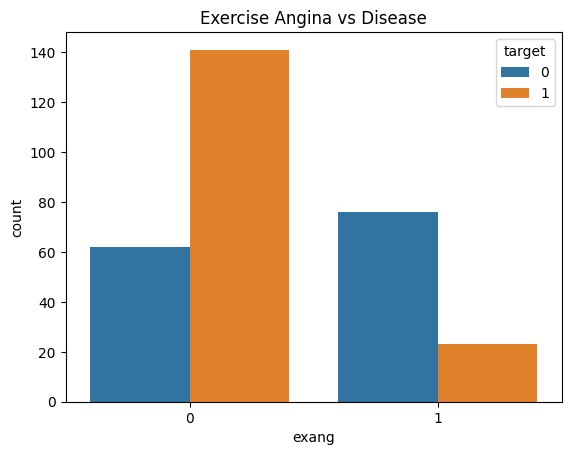

In [ ]:
sns.countplot(x="exang", hue="target", data=df)
plt.title("Exercise Angina vs Disease")
plt.show()

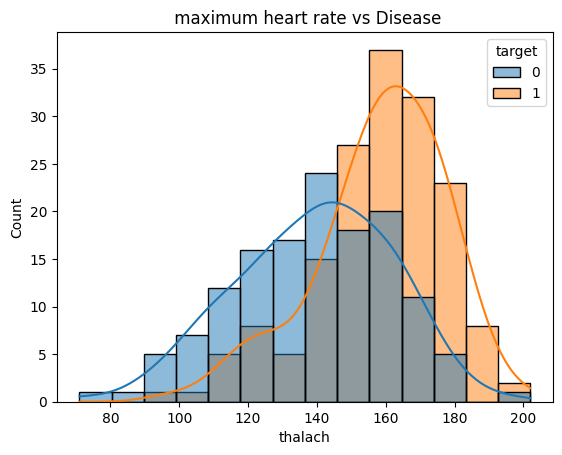

In [ ]:
sns.histplot(data=df, x="thalach", hue="target", kde=True)
plt.title(" maximum heart rate vs Disease")
plt.show()

In [ ]:
df.groupby("sex")["target"].mean()

,target
sex,
0,0.750000
1,0.446602


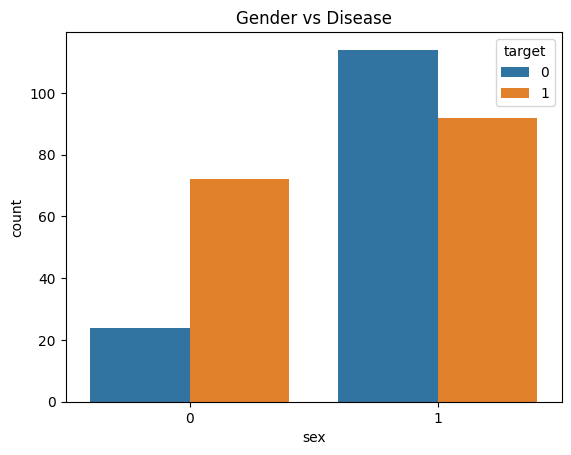

In [ ]:
sns.countplot(x="sex", hue="target", data=df)
plt.title("Gender vs Disease")
plt.show()

In [ ]:
df["age_group"] = pd.cut(df["age"],
                        bins=[20,30,40,50,60,70,80],
                        labels=["20-30","30-40","40-50","50-60","60-70","70-80"])

df.groupby("age_group")["target"].mean() * 100

/tmp/ipykernel_234/3785629124.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["target"].mean() * 100


,target
age_group,
20-30,100.000000
30-40,64.705882
40-50,69.736842
50-60,49.612403
60-70,41.095890
70-80,83.333333


In [ ]:
df["age_group"].value_counts().sort_values(ascending=False)

,count
age_group,
50-60,129
40-50,76
60-70,73
30-40,17
70-80,6
20-30,1


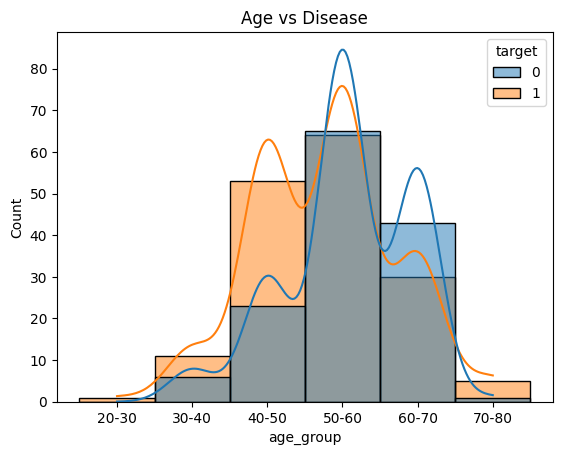

In [ ]:
sns.histplot(data=df, x="age_group", hue="target", kde=True)
plt.title("Age vs Disease")
plt.show()